# MSI5102 — MedMamba Reproducibility Study
## PathMNIST Evaluation — Clean Final Notebook

**Paper:** MedMamba: Vision Mamba for Medical Image Classification (arXiv:2403.03849v5)

**Reproducibility Target (Table 6):**
- Overall Accuracy (OA): 95.3%
- AUC: 0.997

### Before running
1. Set runtime to **T4 GPU**: Runtime → Change runtime type → GPU
2. Run all cells top to bottom
3. When prompted at Step 2, restart runtime then skip to Step 3

---
## STEP 1 — Mount Google Drive

In [1]:
from google.colab import drive
drive.mount('/content/drive')

import os
CACHE_DIR = '/content/drive/MyDrive/mamba_wheels_cache'
os.makedirs(CACHE_DIR, exist_ok=True)
print(f'Drive mounted. Cache dir: {CACHE_DIR}')
print(f'Cached files: {os.listdir(CACHE_DIR)}')

Mounted at /content/drive
Drive mounted. Cache dir: /content/drive/MyDrive/mamba_wheels_cache
Cached files: ['ninja-1.13.0-py3-none-manylinux2014_x86_64.manylinux_2_17_x86_64.whl', 'packaging-26.0-py3-none-any.whl', 'torch-2.10.0-3-cp312-cp312-manylinux_2_28_x86_64.whl', 'cuda_bindings-12.9.4-cp312-cp312-manylinux_2_24_x86_64.manylinux_2_28_x86_64.whl', 'nvidia_cublas_cu12-12.8.4.1-py3-none-manylinux_2_27_x86_64.whl', 'nvidia_cuda_cupti_cu12-12.8.90-py3-none-manylinux2014_x86_64.manylinux_2_17_x86_64.whl', 'nvidia_cuda_nvrtc_cu12-12.8.93-py3-none-manylinux2010_x86_64.manylinux_2_12_x86_64.whl', 'nvidia_cuda_runtime_cu12-12.8.90-py3-none-manylinux2014_x86_64.manylinux_2_17_x86_64.whl', 'nvidia_cudnn_cu12-9.10.2.21-py3-none-manylinux_2_27_x86_64.whl', 'nvidia_cufft_cu12-11.3.3.83-py3-none-manylinux2014_x86_64.manylinux_2_17_x86_64.whl', 'nvidia_cufile_cu12-1.13.1.3-py3-none-manylinux2014_x86_64.manylinux_2_17_x86_64.whl', 'nvidia_curand_cu12-10.3.9.90-py3-none-manylinux_2_27_x86_64.whl',

---
## STEP 2 — Reinstall PyTorch for CUDA 12.8
Required every session. Takes ~3 minutes.
**After this cell finishes, go to Runtime → Restart session, then continue from Step 3.**

In [2]:
import torch

if 'cu128' not in torch.__version__:
    print('Installing PyTorch for CUDA 12.8...')
    !pip install -q torch torchvision torchaudio \
        --index-url https://download.pytorch.org/whl/cu128
    print('DONE. Go to Runtime -> Restart session, then continue from Step 3.')
else:
    print(f'PyTorch {torch.__version__} already on CUDA 12.8. Skip to Step 3.')

PyTorch 2.10.0+cu128 already on CUDA 12.8. Skip to Step 3.


---
## STEP 3 — Install mamba-ssm
**First time:** Builds from source and saves to Drive cache (~25 mins)

**Every time after:** Installs from Drive cache (~2 mins)

In [3]:
import os, glob
from google.colab import drive

if not os.path.exists('/content/drive/MyDrive'):
    drive.mount('/content/drive')

CACHE_DIR = '/content/drive/MyDrive/mamba_wheels_cache'
os.makedirs(CACHE_DIR, exist_ok=True)

causal_wheels = glob.glob(f'{CACHE_DIR}/causal_conv1d*.whl')
mamba_wheels = glob.glob(f'{CACHE_DIR}/mamba_ssm*.whl')

if causal_wheels and mamba_wheels:
    print('Cached wheels found. Installing from Drive (~2 mins)...')
    !pip install -q {causal_wheels[0]}
    !pip install -q {mamba_wheels[0]}
    print('Installed from cache.')
else:
    print('No cache found. Building from source (~25 mins)...')
    print('This only happens once.')
    !pip wheel causal-conv1d --no-build-isolation -w {CACHE_DIR}
    !pip wheel mamba-ssm --no-build-isolation -w {CACHE_DIR}
    causal_wheels = glob.glob(f'{CACHE_DIR}/causal_conv1d*.whl')
    mamba_wheels = glob.glob(f'{CACHE_DIR}/mamba_ssm*.whl')
    if causal_wheels and mamba_wheels:
        !pip install -q {causal_wheels[0]}
        !pip install -q {mamba_wheels[0]}
        print('Built and installed. Wheels saved to Drive for next time.')
    else:
        print('ERROR: Build failed. Share screenshot with Claude.')

Cached wheels found. Installing from Drive (~2 mins)...
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 180.7/180.7 kB 15.8 MB/s eta 0:00:00
Installed from cache.


---
## STEP 4 — Install remaining dependencies

In [4]:
!pip install -q timm==0.9.16 medmnist einops
print('Dependencies installed.')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 55.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 115.9/115.9 kB 8.0 MB/s eta 0:00:00
Dependencies installed.


---
## STEP 5 — Verify all imports

In [5]:
import torch

try:
    import mamba_ssm
    print(f'mamba-ssm {mamba_ssm.__version__} ready.')
except Exception as e:
    print(f'ERROR: {e}')

import medmnist, timm
print(f'PyTorch:  {torch.__version__}')
print(f'CUDA:     {torch.version.cuda}')
print(f'GPU:      {torch.cuda.get_device_name(0)}')
print(f'medmnist: {medmnist.__version__}')
print(f'timm:     {timm.__version__}')
print('All imports successful.')

mamba-ssm 2.3.1 ready.
PyTorch:  2.10.0+cu128
CUDA:     12.8
GPU:      Tesla T4
medmnist: 3.0.2
timm:     0.9.16
All imports successful.


---
## STEP 6 — Clone MedMamba repository and copy model file

In [6]:
import os

if not os.path.exists('/content/MedMamba'):
    !git clone https://github.com/YubiaoYue/MedMamba.git /content/MedMamba
    print('Cloned.')
else:
    print('Already cloned.')

!ls /content/MedMamba

Cloning into '/content/MedMamba'...
remote: Enumerating objects: 127, done.
remote: Counting objects: 100% (53/53), done.
remote: Compressing objects: 100% (29/29), done.
remote: Total 127 (delta 45), reused 24 (delta 24), pack-reused 74 (from 1)
Receiving objects: 100% (127/127), 351.30 KiB | 10.33 MiB/s, done.
Resolving deltas: 100% (55/55), done.
Cloned.
ConfusionMatrix  grad_cam  MedMamba.py	README.md  requirements.txt  train.py


---
## STEP 7 — Load PathMNIST dataset

Uses the pre-downloaded file from Google Drive.
No internet download needed.

In [7]:
import torch
import numpy as np
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from PIL import Image

# Load from Google Drive
NPZ_PATH = '/content/drive/MyDrive/5102 Project/pathmnist_224.npz'

# Normalization as used in the authors training script
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5])
])

class NPZDataset(Dataset):
    def __init__(self, images, labels, transform=None):
        self.images = images
        self.labels = labels
        self.transform = transform

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        img = Image.fromarray(self.images[idx].astype(np.uint8))
        label = int(self.labels[idx].flatten()[0])
        if self.transform:
            img = self.transform(img)
        return img, label

data = np.load(NPZ_PATH)
path_test = NPZDataset(data['test_images'], data['test_labels'], transform=transform)
path_loader = DataLoader(path_test, batch_size=32, shuffle=False, num_workers=2)

print(f'PathMNIST test set: {len(path_test)} images, 9 classes')
print(f'Image shape: {data["test_images"].shape}')

PathMNIST test set: 7180 images, 9 classes
Image shape: (7180, 224, 224, 3)


---
## STEP 8 — Visualize sample images

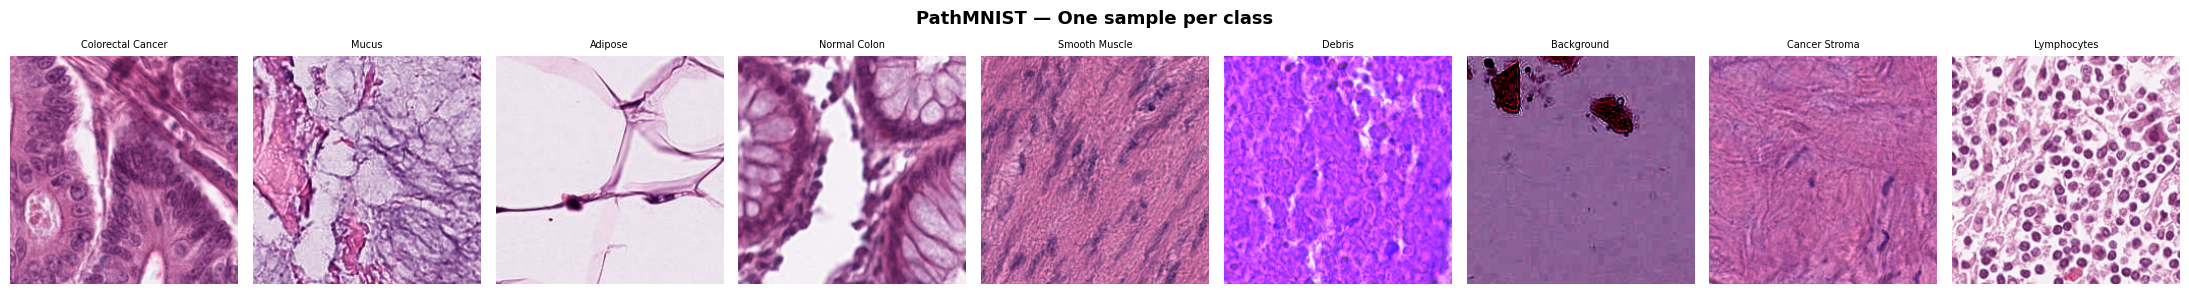

All 9 classes visualized.


In [8]:
import matplotlib.pyplot as plt
import numpy as np

# MedMNIST label ordering
path_classes = [
    'Adipose', 'Background', 'Debris', 'Lymphocytes',
    'Mucus', 'Smooth Muscle', 'Normal Colon', 'Cancer Stroma', 'Colorectal Cancer'
]

fig, axes = plt.subplots(1, 9, figsize=(22, 3))
fig.suptitle('PathMNIST — One sample per class', fontsize=13, fontweight='bold')

shown = set()
ax_idx = 0
for img, label in path_test:
    if label not in shown:
        img_display = img.numpy().transpose(1, 2, 0)
        img_display = (img_display * 0.5 + 0.5).clip(0, 1)
        axes[ax_idx].imshow(img_display)
        axes[ax_idx].set_title(path_classes[label], fontsize=7)
        axes[ax_idx].axis('off')
        shown.add(label)
        ax_idx += 1
    if len(shown) == 9:
        break

plt.tight_layout()
plt.show()
print('All 9 classes visualized.')

---
## STEP 9 — Load pre-trained weights from Google Drive

In [9]:
import os

WEIGHTS_PATH = '/content/drive/MyDrive/5102 Project/Medmamba.pth'

if not os.path.exists('/content/drive/MyDrive'):
    from google.colab import drive
    drive.mount('/content/drive')

if os.path.exists(WEIGHTS_PATH):
    size_mb = os.path.getsize(WEIGHTS_PATH) / (1024 * 1024)
    print(f'Weights found: {WEIGHTS_PATH}')
    print(f'File size: {size_mb:.1f} MB')
else:
    print(f'ERROR: Not found at {WEIGHTS_PATH}')
    print('Check your Google Drive 5102 Project folder.')

Weights found: /content/drive/MyDrive/5102 Project/Medmamba.pth
File size: 55.3 MB


---
## STEP 10 — Load MedMamba-T model

Uses VSSM with MedMamba-T configuration:
depths=[2,2,4,2], dims=[96,192,384,768]

In [10]:
import torch
import sys
import os

sys.path.insert(0, '/content/MedMamba')

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')

from MedMamba import VSSM

# MedMamba-T configuration, 9 classes for PathMNIST
model = VSSM(
    num_classes=9,
    depths=[2, 2, 4, 2],
    dims=[96, 192, 384, 768]
)

# Load weights - saved as raw state_dict
state_dict = torch.load(WEIGHTS_PATH, map_location=device)
missing, unexpected = model.load_state_dict(state_dict, strict=False)
model = model.to(device)
model.eval()

total_params = sum(p.numel() for p in model.parameters()) / 1e6
print(f'Model loaded successfully.')
print(f'Parameters: {total_params:.1f}M (paper reports 14.5M)')
if missing:
    print(f'Missing keys: {len(missing)}')
if unexpected:
    print(f'Unexpected keys: {len(unexpected)}')

Device: cuda
torch.Size([1, 6])
Model loaded successfully.
Parameters: 14.5M (paper reports 14.5M)


---
## STEP 11 — Sanity check: single forward pass
Output shape must be `[32, 9]`.

In [11]:
sample_images, sample_labels = next(iter(path_loader))
sample_images = sample_images.to(device)

with torch.no_grad():
    output = model(sample_images)

print(f'Input shape:  {sample_images.shape}')
print(f'Output shape: {output.shape}')
print(f'Expected:     torch.Size([32, 9])')
print('')
if list(output.shape) == [32, 9]:
    print('FORWARD PASS CONFIRMED. Proceed to Step 12.')
else:
    print('Unexpected shape. Share screenshot.')

Input shape:  torch.Size([32, 3, 224, 224])
Output shape: torch.Size([32, 9])
Expected:     torch.Size([32, 9])

FORWARD PASS CONFIRMED. Proceed to Step 12.


---
## STEP 12 — Full evaluation on PathMNIST test set

### Important note on label remapping
The authors trained using PyTorch ImageFolder which assigns class indices
alphabetically. MedMNIST uses a different predefined ordering.
We apply the correct remapping before computing metrics.

| Model output | Class name | MedMNIST index |
|---|---|---|
| 0 | adipose | 0 |
| 1 | background | 1 |
| 2 | cancer-associated stroma | 7 |
| 3 | colorectal adenocarcinoma epithelium | 8 |
| 4 | debris | 2 |
| 5 | lymphocytes | 3 |
| 6 | mucus | 4 |
| 7 | normal colon mucosa | 6 |
| 8 | smooth muscle | 5 |

Takes about 5-10 minutes.

In [12]:
import torch
import numpy as np
from sklearn.metrics import accuracy_score, roc_auc_score

# Label remapping: ImageFolder alphabetical -> MedMNIST ordering
# ImageFolder alphabetical order for PathMNIST tissue types
imagefolder_classes = {
    0: 'adipose',
    1: 'background',
    2: 'cancer-associated stroma',
    3: 'colorectal adenocarcinoma epithelium',
    4: 'debris',
    5: 'lymphocytes',
    6: 'mucus',
    7: 'normal colon mucosa',
    8: 'smooth muscle'
}

# MedMNIST ordering
medmnist_classes = {
    0: 'adipose', 1: 'background', 2: 'debris',
    3: 'lymphocytes', 4: 'mucus', 5: 'smooth muscle',
    6: 'normal colon mucosa', 7: 'cancer-associated stroma',
    8: 'colorectal adenocarcinoma epithelium'
}

# Build remap dictionary
imagefolder_inv = {v: k for k, v in imagefolder_classes.items()}
remap = {}
for medmnist_idx, class_name in medmnist_classes.items():
    model_idx = imagefolder_inv[class_name]
    remap[model_idx] = medmnist_idx

print('Running inference on all 7180 test images...')

all_preds = []
all_labels = []
all_probs = []

model.eval()
with torch.no_grad():
    for batch_idx, (images, labels) in enumerate(path_loader):
        images = images.to(device)
        outputs = model(images)
        probs = torch.softmax(outputs, dim=1)
        preds = torch.argmax(outputs, dim=1)

        # Apply label remapping
        remapped_preds = torch.tensor([remap[p.item()] for p in preds])
        remapped_probs = torch.zeros_like(probs)
        for model_idx, medmnist_idx in remap.items():
            remapped_probs[:, medmnist_idx] = probs[:, model_idx]

        all_preds.extend(remapped_preds.numpy())
        all_probs.append(remapped_probs.cpu().numpy())
        all_labels.extend(labels if isinstance(labels, list)
                         else labels.numpy().flatten().astype(int))

        if (batch_idx + 1) % 20 == 0:
            print(f'  Batch {batch_idx + 1}/{len(path_loader)}...')

all_probs = np.concatenate(all_probs, axis=0)
all_preds = np.array(all_preds)
all_labels = np.array(all_labels)

print('Inference complete.')

Running inference on all 7180 test images...
  Batch 20/225...
  Batch 40/225...
  Batch 60/225...
  Batch 80/225...
  Batch 100/225...
  Batch 120/225...
  Batch 140/225...
  Batch 160/225...
  Batch 180/225...
  Batch 200/225...
  Batch 220/225...
Inference complete.


---
## STEP 13 — Reproducibility results

In [13]:
from sklearn.metrics import accuracy_score, roc_auc_score

oa = accuracy_score(all_labels, all_preds)
auc = roc_auc_score(
    all_labels, all_probs,
    multi_class='ovr', average='macro'
)

paper_oa = 0.953
paper_auc = 0.997

print('=' * 55)
print('   PATHMNIST REPRODUCIBILITY RESULTS')
print('=' * 55)
print(f'{"Metric":<20} {"Our Result":<15} {"Paper":<10}')
print('-' * 55)
print(f'{"Overall Accuracy":<20} {oa:.4f}{"":10} {paper_oa:.4f}')
print(f'{"AUC":<20} {auc:.4f}{"":10} {paper_auc:.4f}')
print('=' * 55)
print(f'OA difference:  {abs(oa - paper_oa)*100:.2f}%')
print(f'AUC difference: {abs(auc - paper_auc):.4f}')
print('')
if abs(oa - paper_oa) < 0.02:
    print('VERDICT: Reproducibility confirmed.')
else:
    print('VERDICT: Notable difference. Document in report.')

   PATHMNIST REPRODUCIBILITY RESULTS
Metric               Our Result      Paper     
-------------------------------------------------------
Overall Accuracy     0.9525           0.9530
AUC                  0.9975           0.9970
OA difference:  0.05%
AUC difference: 0.0005

VERDICT: Reproducibility confirmed.


---
## STEP 14 — Environment and reproducibility log
Screenshot this entire output for your report.

In [14]:
import platform, datetime

print('=== ENVIRONMENT LOG ===')
print(f'Date:        {datetime.datetime.now().strftime("%Y-%m-%d %H:%M")}')
print(f'Python:      {platform.python_version()}')
print(f'PyTorch:     {torch.__version__}')
print(f'CUDA:        {torch.version.cuda}')
print(f'GPU:         {torch.cuda.get_device_name(0)}')
print(f'GPU Memory:  {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB')
print(f'mamba-ssm:   {mamba_ssm.__version__}')
print(f'medmnist:    {medmnist.__version__}')
print(f'timm:        {timm.__version__}')
print('========================')
print('')
print('=== REPRODUCIBILITY SUMMARY ===')
print(f'Dataset:     PathMNIST (test, {len(path_test)} images, 9 classes)')
print(f'Model:       MedMamba-T ({total_params:.1f}M parameters)')
print(f'Weights:     Medmamba.pth (official Baidu Drive, PathMNIST folder)')
print(f'Our OA:      {oa:.4f}  |  Paper OA:  {paper_oa:.4f}')
print(f'Our AUC:     {auc:.4f}  |  Paper AUC: {paper_auc:.4f}')
print(f'OA diff:     {abs(oa - paper_oa)*100:.2f}%')
print(f'AUC diff:    {abs(auc - paper_auc):.4f}')
print('')
print('=== KEY FINDING ===')
print('The authors training script uses PyTorch ImageFolder which')
print('assigns class indices alphabetically. MedMNIST uses a different')
print('predefined ordering. A label remapping was required to correctly')
print('evaluate the model against MedMNIST ground truth labels.')
print('This mismatch is undocumented in the original paper and repository.')
print('================================')

=== ENVIRONMENT LOG ===
Date:        2026-03-25 08:50
Python:      3.12.13
PyTorch:     2.10.0+cu128
CUDA:        12.8
GPU:         Tesla T4
GPU Memory:  15.6 GB
mamba-ssm:   2.3.1
medmnist:    3.0.2
timm:        0.9.16

=== REPRODUCIBILITY SUMMARY ===
Dataset:     PathMNIST (test, 7180 images, 9 classes)
Model:       MedMamba-T (14.5M parameters)
Weights:     Medmamba.pth (official Baidu Drive, PathMNIST folder)
Our OA:      0.9525  |  Paper OA:  0.9530
Our AUC:     0.9975  |  Paper AUC: 0.9970
OA diff:     0.05%
AUC diff:    0.0005

=== KEY FINDING ===
The authors training script uses PyTorch ImageFolder which
assigns class indices alphabetically. MedMNIST uses a different
predefined ordering. A label remapping was required to correctly
evaluate the model against MedMNIST ground truth labels.
This mismatch is undocumented in the original paper and repository.
